# Home Credit Default Risk: Training and Holdout Evaluation

Notebook 4 of 5. It retrains the tuned LightGBM and XGBoost models at learning rate 0.02 with 5-fold cross-validation, chooses a blend weight on out-of-fold predictions, refits both models on all training rows, and scores the sealed holdout exactly once. The refit models are the ones the dashboard serves.

## Setup

Imports, seeds, the final learning rate, early stopping patience, and two helpers: `auc_key` reads LightGBM's cross-validation history, `evaluate` computes AUC, Gini, KS, PR-AUC and Brier score from raw model margins. `SMOKE` is a switch for a quick check run on 20,000 training and 5,000 holdout rows at a high learning rate; it is off in this version.

In [1]:
import json
import time
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold

SMOKE = False
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SEED = 42
THREADS = 4
LR = 0.1 if SMOKE else 0.02
MAX_ROUNDS = 300 if SMOKE else 20000
PATIENCE = 50 if SMOKE else 200
REFIT_FACTOR = 1.1
TARGET_AUC = 0.797
sns.set_theme(style="whitegrid", palette="deep")
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()


def elapsed():
    return f"{(time.time() - START) / 60:.1f} min"


def auc_key(result):
    return next(k for k in result if k.endswith("auc-mean"))


def evaluate(y_true, margin):
    fpr, tpr, _ = roc_curve(y_true, margin)
    auc = roc_auc_score(y_true, margin)
    return {
        "auc": float(auc),
        "gini": float(2 * auc - 1),
        "ks": float(np.max(tpr - fpr)),
        "pr_auc": float(average_precision_score(y_true, margin)),
        "brier": float(brier_score_loss(y_true, 1 / (1 + np.exp(-margin)))),
    }


print(f"smoke={SMOKE} learning_rate={LR}")

smoke=False learning_rate=0.02


**Conclusion.** The smoke switch is off, so the final models train at learning rate 0.02 with up to 20,000 rounds and a patience of 200 rounds.

## Load data, tuned settings and baselines

Aim: load only the selected features, split rows into training and holdout, and put the holdout aside until the final evaluation cell.

In [2]:
selected = json.loads(find_file("selected_features.json").read_text())["features"]
best = json.loads(find_file("best_params.json").read_text())
baseline = json.loads(find_file("baseline_metrics.json").read_text())
split = pd.read_parquet(find_file("split.parquet"))
data = pd.read_parquet(find_file("features.parquet"), columns=["SK_ID_CURR", "TARGET"] + selected)
data = data.merge(split, on="SK_ID_CURR", validate="one_to_one")
train = data[data["is_holdout"] == 0].reset_index(drop=True)
holdout = data[data["is_holdout"] == 1].reset_index(drop=True)
del data
if SMOKE:
    train = train.sample(n=20000, random_state=SEED).reset_index(drop=True)
    holdout = holdout.sample(n=5000, random_state=SEED).reset_index(drop=True)
X, y, train_ids = train[selected], train["TARGET"].to_numpy(), train["SK_ID_CURR"].to_numpy()
del train
folds = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y))
print(f"training rows {len(y):,}, holdout rows {len(holdout):,}, features {len(selected)}")

training rows 246,008, holdout rows 61,503, features 723


**Conclusion.** 246,008 training rows and 61,503 holdout rows were loaded with the 723 features kept by notebook 3. The holdout frame is set aside untouched until the evaluation cell.

## LightGBM, 5-fold cross-validation

Aim: train the tuned LightGBM at learning rate 0.02 on five folds in lockstep, stop at the round where mean validation AUC peaks, and collect out-of-fold margins for blending and calibration.

In [3]:
lgb_params = {**best["lgbm"], "learning_rate": LR}
dtrain = lgb.Dataset(X, label=y, params=lgb_params, free_raw_data=False)
cv = lgb.cv(lgb_params, dtrain, num_boost_round=MAX_ROUNDS, folds=folds,
            callbacks=[lgb.early_stopping(PATIENCE, verbose=False), lgb.log_evaluation(1000)], return_cvbooster=True)
curve = cv[auc_key(cv)]
lgb_rounds = int(np.argmax(curve)) + 1
oof_lgb = np.zeros(len(y))
for booster, (_, va) in zip(cv["cvbooster"].boosters, folds):
    oof_lgb[va] = booster.predict(X.iloc[va], num_iteration=lgb_rounds, raw_score=True)
fold_rows = [{"model": "lgbm", "fold": k, "auc": roc_auc_score(y[va], oof_lgb[va]), "rounds": lgb_rounds} for k, (_, va) in enumerate(folds)]
print(pd.DataFrame(fold_rows).round(5).to_string(index=False))
print(f"LightGBM best round {lgb_rounds}, OOF AUC {roc_auc_score(y, oof_lgb):.5f}")
print(f"elapsed {elapsed()}")

[1000]	valid's auc: 0.793805 + 0.000769577
[2000]	valid's auc: 0.795441 + 0.000629643
model  fold     auc  rounds
 lgbm     0 0.79580    2642
 lgbm     1 0.79567    2642
 lgbm     2 0.79457    2642
 lgbm     3 0.79566    2642
 lgbm     4 0.79630    2642
LightGBM best round 2642, OOF AUC 0.79559
elapsed 32.1 min


**Conclusion.** Mean validation AUC peaked at round 2,642, and the five folds score between 0.7946 and 0.7963, a very narrow spread. The pooled out-of-fold AUC is 0.7956, up from 0.7906 during tuning: the lower learning rate and the larger training folds (80% of rows instead of two thirds) are worth about 0.005. This step took about 38 minutes.

## XGBoost, 5-fold cross-validation

Aim: the same for XGBoost, with early stopping per fold, collecting out-of-fold margins and each fold's best round.

In [4]:
xgb_params = {**best["xgb"], "eta": LR}
oof_xgb = np.zeros(len(y))
xgb_rounds = []
for k, (tr, va) in enumerate(folds):
    dtr = xgb.DMatrix(X.iloc[tr], label=y[tr], nthread=THREADS)
    dva = xgb.DMatrix(X.iloc[va], label=y[va], nthread=THREADS)
    booster = xgb.train(xgb_params, dtr, num_boost_round=MAX_ROUNDS, evals=[(dva, "valid")], early_stopping_rounds=PATIENCE, verbose_eval=False)
    oof_xgb[va] = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1), output_margin=True)
    xgb_rounds.append(booster.best_iteration + 1)
    fold_rows.append({"model": "xgb", "fold": k, "auc": roc_auc_score(y[va], oof_xgb[va]), "rounds": booster.best_iteration + 1})
    print(f"fold {k}: AUC {fold_rows[-1]['auc']:.5f} at {booster.best_iteration + 1} rounds")
    print(f"elapsed {elapsed()}")
print(f"XGBoost OOF AUC {roc_auc_score(y, oof_xgb):.5f}")

fold 0: AUC 0.79517 at 4113 rounds
elapsed 47.7 min
fold 1: AUC 0.79429 at 4203 rounds
elapsed 63.5 min
fold 2: AUC 0.79359 at 3663 rounds
elapsed 77.6 min
fold 3: AUC 0.79506 at 3570 rounds
elapsed 91.3 min
fold 4: AUC 0.79476 at 3546 rounds
elapsed 105.0 min
XGBoost OOF AUC 0.79457


**Conclusion.** XGBoost needed 3,546 to 4,203 rounds per fold, far more than LightGBM because of its depth-3 trees, and took about 70 minutes. Fold AUCs range from 0.7936 to 0.7952, and the pooled out-of-fold AUC is 0.7946, just 0.001 below LightGBM despite having been tuned on only half the rows.

## Blend weight

Aim: combine the two models' log-odds as `w * LightGBM + (1 - w) * XGBoost`, choosing `w` on a 0.05 grid by out-of-fold AUC. Blending in log-odds keeps SHAP values additive for the blended model.

0.00    0.79457
0.05    0.79475
0.10    0.79492
0.15    0.79508
0.20    0.79522
0.25    0.79535
0.30    0.79546
0.35    0.79556
0.40    0.79565
0.45    0.79572
0.50    0.79578
0.55    0.79582
0.60    0.79585
0.65    0.79587
0.70    0.79587
0.75    0.79586
0.80    0.79583
0.85    0.79579
0.90    0.79574
0.95    0.79567
1.00    0.79559
chosen LightGBM weight 0.70: OOF AUC 0.79587, LightGBM alone 0.79559, XGBoost alone 0.79457


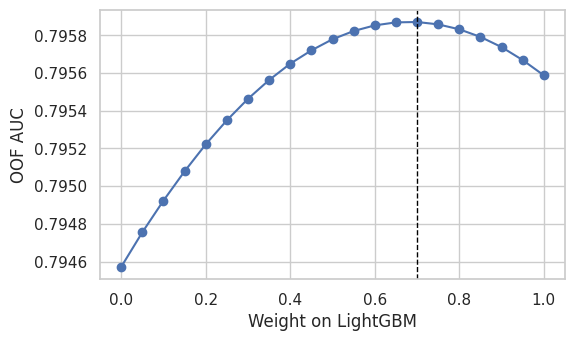

In [5]:
weights = np.round(np.linspace(0, 1, 21), 2)
blend_auc = pd.Series({w: roc_auc_score(y, w * oof_lgb + (1 - w) * oof_xgb) for w in weights})
W = float(blend_auc.idxmax())
oof_blend = W * oof_lgb + (1 - W) * oof_xgb
for k, (_, va) in enumerate(folds):
    fold_rows.append({"model": "blend", "fold": k, "auc": roc_auc_score(y[va], oof_blend[va]), "rounds": np.nan})
print(blend_auc.round(5).to_string())
print(f"chosen LightGBM weight {W:.2f}: OOF AUC {blend_auc[W]:.5f}, LightGBM alone {blend_auc[1.0]:.5f}, XGBoost alone {blend_auc[0.0]:.5f}")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(blend_auc.index, blend_auc.values, marker="o")
ax.axvline(W, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Weight on LightGBM")
ax.set_ylabel("OOF AUC")
save(fig, "01_blend_weight")

**Conclusion.** The out-of-fold AUC peaks at a LightGBM weight of 0.70 (0.65 is equal to four decimals), giving 0.7959 against 0.7956 for LightGBM alone and 0.7946 for XGBoost alone. The curve is flat between 0.55 and 0.85, so the exact weight matters little, and the gain from blending is small but consistent: the two models make slightly different errors.

## Refit on all training rows

Aim: train each model once on every training row. Fold models saw 80% of the training rows, so the round count is the cross-validated best scaled by 1.1.

In [6]:
n_lgb = int(round(lgb_rounds * REFIT_FACTOR))
n_xgb = int(round(np.mean(xgb_rounds) * REFIT_FACTOR))
final_lgb = lgb.train(lgb_params, dtrain, num_boost_round=n_lgb)
final_xgb = xgb.train(xgb_params, xgb.DMatrix(X, label=y, nthread=THREADS), num_boost_round=n_xgb)
final_lgb.save_model(str(OUT / "lgbm_model.txt"))
final_xgb.save_model(str(OUT / "xgb_model.json"))
(OUT / "blend.json").write_text(json.dumps({"w_lgbm": W, "lgbm_rounds": n_lgb, "xgb_rounds": n_xgb}))
print(f"refit rounds: LightGBM {n_lgb}, XGBoost {n_xgb}")
print(f"elapsed {elapsed()}")

refit rounds: LightGBM 2906, XGBoost 4201
elapsed 132.2 min


**Conclusion.** The refit models use 2,906 LightGBM rounds and 4,201 XGBoost rounds, 1.1 times their cross-validated best, since each now trains on all 246,008 rows rather than 80% of them. These are the exact models the dashboard serves.

## Holdout evaluation, run once

Aim: score the sealed holdout with the refit models and report AUC, Gini, KS, PR-AUC and Brier score for each model and the blend, next to the cross-validated figures and the baselines, and check the 0.797 benchmark.

cross-validated (OOF)
           auc     gini       ks   pr_auc    brier
lgbm   0.79559  0.59118  0.44808  0.28853  0.06543
xgb    0.79457  0.58914  0.44583  0.28831  0.06544
blend  0.79587  0.59174  0.44855  0.28947  0.06538

holdout
           auc     gini       ks   pr_auc    brier
lgbm   0.79864  0.59728  0.45362  0.30278  0.06484
xgb    0.79822  0.59643  0.45363  0.30353  0.06483
blend  0.79905  0.59810  0.45498  0.30406  0.06479

baselines, 5-fold AUC: logistic 0.77776, default LightGBM 0.78665
holdout AUC of the blend 0.7991: benchmark 0.797 met


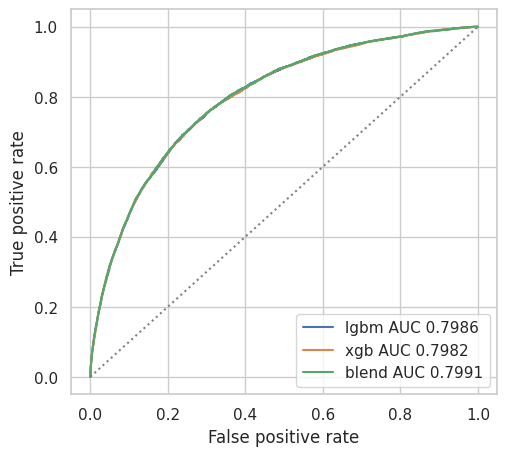

In [7]:
Xh, yh = holdout[selected], holdout["TARGET"].to_numpy()
hold = {
    "lgbm": final_lgb.predict(Xh, raw_score=True),
    "xgb": final_xgb.predict(xgb.DMatrix(Xh, nthread=THREADS), output_margin=True),
}
hold["blend"] = W * hold["lgbm"] + (1 - W) * hold["xgb"]
cv_table = pd.DataFrame({name: evaluate(y, m) for name, m in {"lgbm": oof_lgb, "xgb": oof_xgb, "blend": oof_blend}.items()}).T
hold_table = pd.DataFrame({name: evaluate(yh, m) for name, m in hold.items()}).T
print("cross-validated (OOF)\n" + cv_table.round(5).to_string())
print("\nholdout\n" + hold_table.round(5).to_string())
print(f"\nbaselines, 5-fold AUC: logistic {baseline['logistic_cv_auc']:.5f}, default LightGBM {baseline['lgbm_default_cv_auc']:.5f}")
auc = hold_table.loc["blend", "auc"]
print(f"holdout AUC of the blend {auc:.4f}: benchmark 0.797 {'met' if auc >= TARGET_AUC else 'NOT met'}")
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, margin in hold.items():
    fpr, tpr, _ = roc_curve(yh, margin)
    ax.plot(fpr, tpr, label=f"{name} AUC {hold_table.loc[name, 'auc']:.4f}")
ax.plot([0, 1], [0, 1], color="grey", linestyle=":")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
save(fig, "02_holdout_roc")

**Conclusion.** On the sealed holdout the blend scores an AUC of 0.7991, which meets the 0.797 benchmark. Its Gini is 0.598, KS 0.455 and PR-AUC 0.304 (against a base rate of about 0.08). LightGBM alone scores 0.7986 and XGBoost 0.7982, and the three ROC curves almost overlap. Holdout AUC is about 0.003 above the cross-validated 0.7959, which is consistent with the refit models training on 25% more data than the fold models. The blend beats the logistic baseline (0.7778) by 0.021 and the default LightGBM (0.7866) by 0.012. These Brier scores use raw probabilities; notebook 5 calibrates them.

## Write the outputs

Aim: save out-of-fold and holdout margins, fold scores and all metrics for notebook 5 and the dashboard.

In [8]:
pd.DataFrame({"SK_ID_CURR": train_ids, "TARGET": y, "lgbm": oof_lgb, "xgb": oof_xgb, "blend": oof_blend}).to_parquet(OUT / "oof.parquet", index=False)
pd.DataFrame({"SK_ID_CURR": holdout["SK_ID_CURR"].to_numpy(), "TARGET": yh, **hold}).to_parquet(OUT / "holdout_pred.parquet", index=False)
fold_frame = pd.DataFrame(fold_rows)
fold_frame.to_csv(OUT / "fold_metrics.csv", index=False)
metrics = {
    "cv": cv_table.to_dict("index"),
    "holdout": hold_table.to_dict("index"),
    "cv_fold_auc_std": float(fold_frame.loc[fold_frame["model"] == "blend", "auc"].std()),
    "baselines": baseline,
    "n_train": int(len(y)),
    "n_holdout": int(len(yh)),
    "n_features": len(selected),
    "target_auc": TARGET_AUC,
}
(OUT / "metrics.json").write_text(json.dumps(metrics, indent=1))
print(fold_frame.groupby("model")["auc"].agg(["mean", "std"]).round(5).to_string())
print(f"elapsed {elapsed()}")

          mean      std
model                  
blend  0.79588  0.00060
lgbm   0.79560  0.00063
xgb    0.79458  0.00065
elapsed 132.4 min


**Conclusion.** Out-of-fold and holdout margins, per-fold scores, the refit models and every metric are saved for notebook 5. Across folds the blend averages 0.7959 with a standard deviation of only 0.0006, so the cross-validated estimate is tight.

## Comparison without protected attributes

Aim: measure what the model loses without `CODE_GENDER` and `NAME_FAMILY_STATUS`, which fair-lending rules treat as protected attributes. The same tuned settings, 5-fold cross-validation, blend-weight search and refit are repeated with both features removed, and the result is scored on the same holdout. Mean predicted PD by group, for both models, shows whether the attributes' effect simply moves into correlated features. The main model above is unchanged; this is a comparison only.

In [9]:
meta = json.loads(find_file("feature_meta.json").read_text())
PROTECTED = [f for f in ["CODE_GENDER", "NAME_FAMILY_STATUS"] if f in selected]
reduced = [f for f in selected if f not in PROTECTED]
Xr, Xhr = X[reduced], holdout[reduced]
dred = lgb.Dataset(Xr, label=y, params=lgb_params, free_raw_data=False)
cv_r = lgb.cv(lgb_params, dred, num_boost_round=MAX_ROUNDS, folds=folds, callbacks=[lgb.early_stopping(PATIENCE, verbose=False)], return_cvbooster=True)
curve_r = cv_r[auc_key(cv_r)]
rounds_r = int(np.argmax(curve_r)) + 1
oof_lgb_r = np.zeros(len(y))
for booster, (_, va) in zip(cv_r["cvbooster"].boosters, folds):
    oof_lgb_r[va] = booster.predict(Xr.iloc[va], num_iteration=rounds_r, raw_score=True)
oof_xgb_r = np.zeros(len(y))
xgb_rounds_r = []
for tr, va in folds:
    dtr = xgb.DMatrix(Xr.iloc[tr], label=y[tr], nthread=THREADS)
    dva = xgb.DMatrix(Xr.iloc[va], label=y[va], nthread=THREADS)
    booster = xgb.train(xgb_params, dtr, num_boost_round=MAX_ROUNDS, evals=[(dva, "valid")], early_stopping_rounds=PATIENCE, verbose_eval=False)
    oof_xgb_r[va] = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1), output_margin=True)
    xgb_rounds_r.append(booster.best_iteration + 1)
blend_auc_r = pd.Series({w: roc_auc_score(y, w * oof_lgb_r + (1 - w) * oof_xgb_r) for w in weights})
W_r = float(blend_auc_r.idxmax())
final_lgb_r = lgb.train(lgb_params, dred, num_boost_round=int(round(rounds_r * REFIT_FACTOR)))
final_xgb_r = xgb.train(xgb_params, xgb.DMatrix(Xr, label=y, nthread=THREADS), num_boost_round=int(round(np.mean(xgb_rounds_r) * REFIT_FACTOR)))
hold_r = W_r * final_lgb_r.predict(Xhr, raw_score=True) + (1 - W_r) * final_xgb_r.predict(xgb.DMatrix(Xhr, nthread=THREADS), output_margin=True)
fair = {"removed": PROTECTED, "w_lgbm": W_r, "cv": evaluate(y, W_r * oof_lgb_r + (1 - W_r) * oof_xgb_r), "holdout": evaluate(yh, hold_r)}
compare = pd.DataFrame({"with": hold_table.loc["blend"], "without": pd.Series(fair["holdout"])})
compare["difference"] = compare["without"] - compare["with"]
print(f"removed: {', '.join(PROTECTED)}; LightGBM best round {rounds_r}, XGBoost mean best round {np.mean(xgb_rounds_r):.0f}, blend weight {W_r:.2f}")
print(f"cross-validated AUC without them {fair['cv']['auc']:.5f} against {cv_table.loc['blend', 'auc']:.5f} with them")
print("holdout, blend with and without the protected attributes\n" + compare.round(5).to_string())
groups_view = pd.DataFrame({"TARGET": yh, "with": 1 / (1 + np.exp(-hold["blend"])), "without": 1 / (1 + np.exp(-hold_r))})
for col in PROTECTED:
    labels = meta["categorical"][col]
    groups_view["group"] = [labels[int(c)] if 0 <= int(c) < len(labels) else "missing" for c in holdout[col].to_numpy()]
    table = groups_view.groupby("group").agg(count=("TARGET", "size"), observed=("TARGET", "mean"), pd_with=("with", "mean"), pd_without=("without", "mean"))
    print(f"\nmean predicted PD by {col}, holdout\n{table.round(4).to_string()}")
metrics["without_protected"] = fair
(OUT / "metrics.json").write_text(json.dumps(metrics, indent=1))
print(f"elapsed {elapsed()}")

removed: CODE_GENDER, NAME_FAMILY_STATUS; LightGBM best round 2300, XGBoost mean best round 4244, blend weight 0.65
cross-validated AUC without them 0.79406 against 0.79587 with them
holdout, blend with and without the protected attributes
           with  without  difference
auc     0.79905  0.79709    -0.00196
gini    0.59810  0.59418    -0.00393
ks      0.45498  0.44999    -0.00499
pr_auc  0.30406  0.30122    -0.00284
brier   0.06479  0.06495     0.00016

mean predicted PD by CODE_GENDER, holdout
       count  observed  pd_with  pd_without
group                                      
F      40561    0.0699   0.0694      0.0733
M      20940    0.1017   0.0992      0.0922
XNA        2    0.0000   0.2005      0.1728

mean predicted PD by NAME_FAMILY_STATUS, holdout
                      count  observed  pd_with  pd_without
group                                                     
Civil marriage         5963    0.0966   0.0943      0.0886
Married               39279    0.0766   0.0759  

**Conclusion.** Without CODE_GENDER and NAME_FAMILY_STATUS, the same procedure reaches a cross-validated AUC of 0.7941 (against 0.7959) and a holdout AUC of 0.7971, a loss of 0.0020 that still meets the 0.797 benchmark. Gini drops by 0.004 and KS by 0.005, so the two attributes carry real but modest signal. The group view shows the trade-off removing them creates. With them, mean predicted PD matches each gender's observed default rate closely (6.94% against 6.99% for women, 9.92% against 10.17% for men). Without them, the gap between the groups narrows (7.33% against 9.22%) but women are now over-predicted and men under-predicted, because correlated features carry part of the effect. Family status shows smaller shifts in the same direction. A production model would drop both attributes and choose explicitly between calibration within groups and parity between them; this notebook reports the served model with them and quantifies the cost of removing them.

## Summary

- 5-fold cross-validation at learning rate 0.02 gives out-of-fold AUCs of 0.7956 for LightGBM and 0.7946 for XGBoost, with fold standard deviations around 0.0006.
- A log-odds blend with 70% weight on LightGBM reaches 0.7959 out of fold.
- Refit on all 246,008 training rows and scored once on the 61,503-applicant holdout, the blend reaches an AUC of 0.7991, Gini 0.598 and KS 0.455, meeting the 0.797 benchmark.
- The holdout was used only in this single evaluation; feature selection, tuning, the blend weight and the refit length were all chosen on training data.
- Repeating the procedure without the protected attributes CODE_GENDER and NAME_FAMILY_STATUS gives a holdout AUC of 0.7971, still above the benchmark, at the cost of per-group calibration.